In [22]:
%load_ext autoreload
%autoreload 2
%reset -f

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [23]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import pandas as pd
import geopandas as gpd
import contextily as ctx
import pandas as pd
import os

import sys
import os

%matplotlib widget
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from h3 import *
from shapely.geometry import Point
from shapely.geometry import LineString, Point
import numpy as np

os.chdir('/home/sandbox/personal-repos/DA-3507/dump')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../lib')))
from custom_pandas import *

## Query the surveys

In [24]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[50]].copy()

## Query the geometries

In [25]:
report_bc.db.set_query(query_SurveyH3Aggregation_byReport(report_table = '#TempReport'))
agg_segments =report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

## Isolate a single survey

In [26]:
l = 0
surveys = segments['SurveyId'].unique()
survey = segments[segments['SurveyId'] == surveys[l]]
#survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

/tmp/ipykernel_52453/3614139279.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)


## Prepare the countour geometry

In [27]:
contour = agg_segments[agg_segments['SurveyId'] == surveys[l]]
contour['Breadcrumb_wkt'] = contour['Breadcrumb'].apply(wkt.loads)
contour_gdf = gpd.GeoDataFrame(contour, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
contour_gdf = contour_gdf.to_crs(utm_crs)
contour_gdf['offset'] = contour_gdf.geometry.buffer(5, cap_style=2)


/tmp/ipykernel_52453/3952355739.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contour['Breadcrumb_wkt'] = contour['Breadcrumb'].apply(wkt.loads)


## Create a evenly spaced grid over the line

In [28]:
def sample_linearly(line, distance):
    if not isinstance(line, LineString):
        return []
    length = line.length
    # Compute evenly spaced distances along the line, but exclude endpoints
    num_points = int(np.floor(length / distance)) + 1
    if np.isclose(num_points * distance, length):
        distances = np.linspace(0, length, num=num_points + 1)
    else:
        distances = np.arange(0, length, distance)
        if length not in distances:
            distances = np.append(distances, length)
    # Remove starting (0) and ending (length) point
    distances = [d for d in distances if not np.isclose(d, 0) and not np.isclose(d, length)]
    return [line.interpolate(d) for d in distances]

survey_gdf['EvenlySpaced'] = survey_gdf.geometry.apply(lambda line: sample_linearly(line, 20))
#survey_gdf['EvenlySpaced'] = survey_gdf.geometry.segmentize(20)

# Create the geometry from list of points, plot the result
survey_gdf['EvenlySpacedLine'] = survey_gdf['EvenlySpaced'].apply(lambda pts: LineString(pts) if len(pts) >= 2 else None)
#survey_gdf['EvenlySpacedLine'] = survey_gdf['EvenlySpaced']

survey_gdf['EvenlySpacedLine']

0     LINESTRING (364316.5519297229 5782848.85353550...
1     LINESTRING (364536.57701951126 5783775.9999866...
2     LINESTRING (364204.33437592164 5784362.4004375...
3     LINESTRING (364573.1493071224 5783821.49593748...
4     LINESTRING (364109.69563394104 5784357.9156989...
5     LINESTRING (364109.6921796228 5784175.34664546...
6     LINESTRING (364822.4514099303 5783458.76891655...
7     LINESTRING (364683.04669836495 5783354.5956951...
8     LINESTRING (364835.41191067937 5783456.2913118...
9     LINESTRING (364602.4462809724 5783236.90182507...
10    LINESTRING (364188.19007216726 5784388.1200675...
11    LINESTRING (364422.9694164788 5784030.97683003...
12    LINESTRING (364631.40791250486 5783253.2394590...
13    LINESTRING (364503.31275676284 5783695.7391192...
14    LINESTRING (364564.0637901834 5783488.52900630...
15    LINESTRING (364508.7972987831 5783855.97161459...
16    LINESTRING (364132.0340203735 5784014.33197667...
17    LINESTRING (364270.60485658597 5784207.890

# Create a line perpendicular line at each vertex

In [29]:
import numpy as np
from shapely.geometry import LineString, Point

def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def perpendicular_vector(dx, dy):
    """ Returns a perpendicular vector (to the left of direction of travel). """
    return np.array([-dy, dx])

def perp_lines_at_vertices(line, length=10):
    """Generate perpendicular lines at each vertex of a LineString."""
    coords = list(line.coords)
    perps = []
    n = len(coords)

    for i, (x, y) in enumerate(coords):
        # For endpoints, use segment direction from second/previous point
        if n < 2:
            continue  # Not enough points
        elif i == 0:
            x2, y2 = coords[i + 1]
            dx, dy = x2 - x, y2 - y
        elif i == n - 1:
            x1, y1 = coords[i - 1]
            dx, dy = x - x1, y - y1
        else:
            # Average both directions for a smoother result
            x1, y1 = coords[i - 1]
            x2, y2 = coords[i + 1]
            dx1, dy1 = x - x1, y - y1
            dx2, dy2 = x2 - x, y2 - y
            dx, dy = unit_vector(np.array([dx1, dy1])) + unit_vector(np.array([dx2, dy2]))
            if np.linalg.norm([dx, dy]) == 0:  # colinear back-to-back turn, fallback
                dx, dy = -dy1, dx1

        direction = unit_vector(np.array([dx, dy]))
        perp = perpendicular_vector(*direction)
        midpoint = np.array([x, y])
        half = (length / 2.0) * perp
        line_pts = [midpoint - half, midpoint + half]
        perps.append(LineString(line_pts))

    return perps

perp_lines = []
for geom in survey_gdf.EvenlySpacedLine:
    if isinstance(geom, LineString):
        perp_lines.extend(perp_lines_at_vertices(geom, length=10))

perp_gdf = gpd.GeoDataFrame(geometry=perp_lines, crs=survey_gdf.crs if hasattr(survey_gdf, 'crs') else None)
perp_gdf = perp_gdf.reset_index(drop=True)
perp_gdf.index = pd.Index(range(len(perp_gdf)), name='perp_id')

# Remove close lines

In [45]:
from sklearn.cluster import DBSCAN

# Cluster the samples (midpoints) that are closer than 10 meters
midpoints = perp_gdf.geometry.apply(lambda line: line.interpolate(0.5, normalized=True))
midpoint_coords = np.array([[pt.x, pt.y] for pt in midpoints])

# Apply DBSCAN clustering with eps=10 meters (distance threshold)
dbscan = DBSCAN(eps=5, min_samples=1)
cluster_labels = dbscan.fit_predict(midpoint_coords)
perp_gdf["cluster"] = cluster_labels
perp_gdf

,geometry,cluster
perp_id,,
0,"LINESTRING (364320.299 5782845.543, 364312.805...",0
1,"LINESTRING (364333.540 5782860.533, 364326.045...",1
2,"LINESTRING (364346.781 5782875.522, 364339.286...",2
3,"LINESTRING (364360.022 5782890.511, 364352.527...",3
4,"LINESTRING (364373.263 5782905.501, 364365.768...",4
...,...,...
266,"LINESTRING (364632.526 5783231.316, 364623.280...",245
267,"LINESTRING (364642.622 5783245.363, 364636.108...",246
268,"LINESTRING (364658.993 5783253.567, 364655.018...",247


In [46]:
perp_gdf['cluster'].value_counts()

cluster
20     3
15     3
21     3
16     3
97     2
      ..
90     1
91     1
92     1
93     1
249    1
Name: count, Length: 250, dtype: int64

In [32]:
from shapely.geometry import Point

# Create circles with center at the midpoint of each line, diameter equal to line length
def circle_from_line(line):
    center = line.interpolate(0.5, normalized=True)
    diameter = line.length
    return center.buffer(diameter / 2.0)

circle_gdf = gpd.GeoDataFrame(
    geometry=perp_gdf.geometry.apply(circle_from_line),
    crs=perp_gdf.crs
)
circle_gdf

,geometry
perp_id,
0,"POLYGON ((364321.552 5782848.854, 364321.528 5..."
1,"POLYGON ((364334.793 5782863.843, 364334.769 5..."
2,"POLYGON ((364348.034 5782878.832, 364348.010 5..."
3,"POLYGON ((364361.275 5782893.821, 364361.250 5..."
4,"POLYGON ((364374.515 5782908.811, 364374.491 5..."
...,...
266,"POLYGON ((364632.903 5783233.221, 364632.879 5..."
267,"POLYGON ((364644.365 5783249.157, 364644.341 5..."
268,"POLYGON ((364662.005 5783258.155, 364661.981 5..."


# Create the intersection for getting the number of passes

In [33]:
points = gpd.overlay(perp_gdf, survey_gdf, how='intersection', keep_geom_type=False)[['geometry','Order']]
# Expand any MultiPoint into two points (or more, as many as present), else leave as is
expanded_points = []
for geom in points['geometry']:
    if geom.geom_type == 'MultiPoint':
        expanded_points.extend(list(geom.geoms)[:2])  # take first 2 points
    else:
        expanded_points.append(geom)
expanded_points = gpd.GeoDataFrame(geometry=expanded_points, crs=points.crs if hasattr(points, 'crs') else None)
buffered_points = expanded_points.buffer(0.001)

In [34]:
buffered_points_gdf = gpd.GeoDataFrame(geometry=buffered_points, crs=expanded_points.crs if hasattr(expanded_points, 'crs') else None)
buffered_points_gdf

,geometry
0,"POLYGON ((364316.553 5782848.854, 364316.553 5..."
1,"POLYGON ((364329.794 5782863.843, 364329.794 5..."
2,"POLYGON ((364343.035 5782878.832, 364343.035 5..."
3,"POLYGON ((364356.276 5782893.821, 364356.276 5..."
4,"POLYGON ((364369.516 5782908.811, 364369.516 5..."
...,...
410,"POLYGON ((364627.904 5783233.221, 364627.904 5..."
411,"POLYGON ((364639.366 5783249.157, 364639.366 5..."
412,"POLYGON ((364657.006 5783258.155, 364657.006 5..."
413,"POLYGON ((364675.822 5783264.934, 364675.822 5..."


In [35]:
joined = gpd.sjoin(buffered_points_gdf, perp_gdf, how='left', predicate='intersects')

In [36]:
# Join the count of points (number of passes) with perp_gdf by perp_id
count_by_perp = joined['index_right'].value_counts().rename_axis('perp_id').reset_index(name='count')
perp_gdf_with_count = perp_gdf.reset_index().merge(count_by_perp, on='perp_id', how='left').set_index('perp_id')
perp_gdf_with_count

,geometry,cluster,count
perp_id,,,
0,"LINESTRING (364320.299 5782845.543, 364312.805...",0,1
1,"LINESTRING (364333.540 5782860.533, 364326.045...",1,1
2,"LINESTRING (364346.781 5782875.522, 364339.286...",2,1
3,"LINESTRING (364360.022 5782890.511, 364352.527...",3,1
4,"LINESTRING (364373.263 5782905.501, 364365.768...",4,1
...,...,...,...
266,"LINESTRING (364632.526 5783231.316, 364623.280...",200,1
267,"LINESTRING (364642.622 5783245.363, 364636.108...",79,1
268,"LINESTRING (364658.993 5783253.567, 364655.018...",201,1


# Check the histograms

In [37]:
perp_gdf_with_count['count'].value_counts()

count
1    161
2     76
3     34
Name: count, dtype: int64

<Axes: >

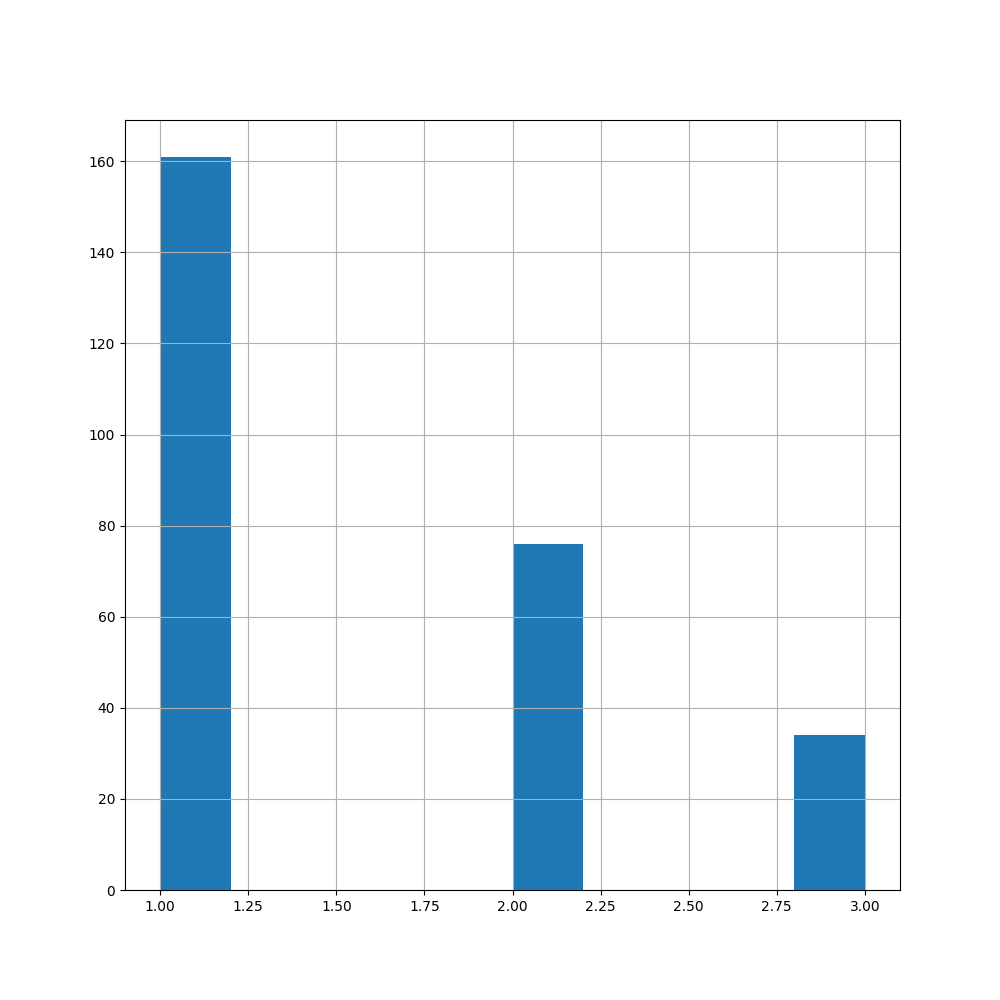

In [38]:

fig,axr = plt.subplots(figsize=(10,10))
perp_gdf_with_count['count'].hist(ax=axr)


# Plotting

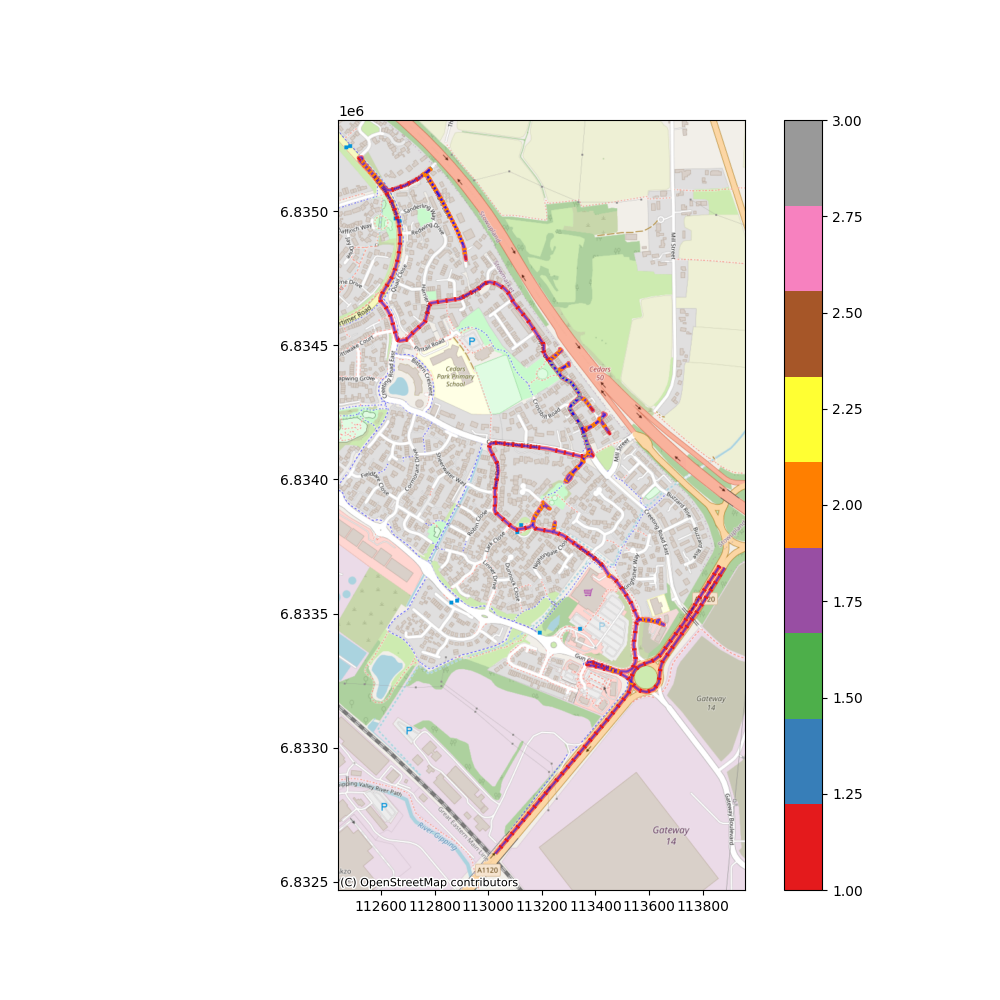

In [39]:
import contextily as ctx

fig, axr = plt.subplots(figsize=(10,10))

survey_gdf.to_crs(epsg=3857).plot(ax=axr, color='blue', alpha=0.5)
perp_gdf_with_count.to_crs(epsg=3857).plot(ax=axr, legend=True, column='count', cmap='Set1')
contour_gdf.offset.to_crs(epsg=3857).plot(ax=axr, color='red', alpha=0.5)

ctx.add_basemap(axr, source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:3857')